In [1]:
import pymcel as pc


Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from scipy.integrate import solve_ivp
deg = np.pi/180
rad = 180/np.pi

In [8]:
#escribir rutina para pendulo simple
def pendulo_simple(t,Ys, g, L):
    theta, u = Ys
    dtheta_dt = u
    du_dt = - (g/L) * np.sin(theta)
    return [dtheta_dt, du_dt]

In [12]:
pendulo_simple(1,[2,3],4,5)

[3, np.float64(-0.7274379414605454)]

In [16]:
ts = np.linspace(0, 10, 100) # [s]
Y0s = [40*deg, 0] #
g = 9.8
L = 1.0
sol = solve_ivp(pendulo_simple,[ts[0], ts[-1]], Y0s, args=(g, L), t_eval=ts)
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-01 ...  9.899e+00  1.000e+01]
        y: [[ 6.981e-01  6.662e-01 ...  1.579e-01  3.559e-01]
            [ 0.000e+00 -6.281e-01 ...  2.072e+00  1.818e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 224
     njev: 0
      nlu: 0

In [ ]:
#variables de configuracion
tethas = sol.y[0]
us = sol.y[1]

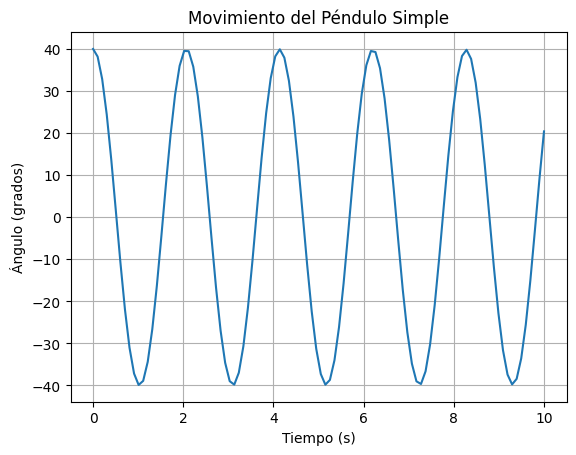

In [15]:
plt.plot(ts, tethas*rad)
plt.xlabel('Tiempo (s)')
plt.ylabel('Ángulo (grados)')
plt.title('Movimiento del Péndulo Simple')
plt.grid()
plt.show()

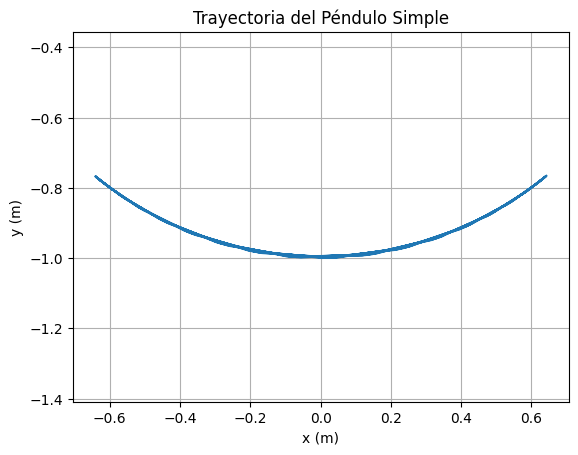

In [17]:
#Coordenadas del péndulo
xs = L * np.sin(tethas)
ys = -L * np.cos(tethas)
plt.plot(xs, ys)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trayectoria del Péndulo Simple')
plt.grid()
plt.axis('equal')
plt.show()

(np.float64(-0.7051735036009604),
 np.float64(0.7069762341288012),
 np.float64(-1.0499859088617516),
 np.float64(0.04999932899341675))

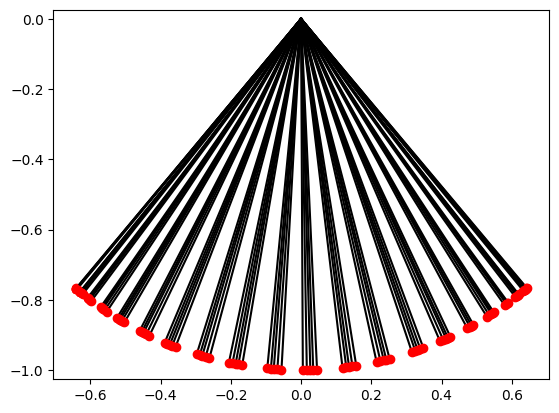

In [18]:
#animacion del péndulo
fig, ax = plt.subplots()
camera = Camera(fig)
for i, ts in enumerate(ts):
    plt.plot([0, xs[i]], [0, ys[i]], 'k-') # cuerda del péndulo
    plt.plot(xs[i], ys[i], 'ro')
    camera.snap()
plt.axis('equal')

In [19]:
from IPython.display import HTML
animation = camera.animate()
HTML(animation.to_jshtml())


In [ ]:
#pendulo elastico
